# SVR Multi-step Forecasting Strategies

本 Notebook 基于 GEFCom2014 数据集，使用 SVR 实现三种多步预测策略：
- **Iterated**：单步模型迭代预测
- **Direct**：每个预测步长独立训练模型
- **MIMO**：多输入多输出（选做）

In [12]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from MSVR import MSVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 兼容从项目根目录或 week2/ 目录启动 kernel 两种情况
_cwd = os.getcwd()
_week2_dir = os.path.join(_cwd, 'week2') if os.path.isdir(os.path.join(_cwd, 'week2')) else _cwd
sys.path.insert(0, _week2_dir)
from data import GEFCom2014

## 1. 数据准备

In [13]:
D_NUM = 24  # 回看窗口（小时）
H_NUM = 24  # 预测步长（小时）

gefcom2014 = GEFCom2014()

In [14]:
# 训练集：X_tr_3d (n, D_NUM, n_features)  y_train (n, H_NUM)
X_tr_3d, y_train = gefcom2014.get_slided_dataset(d_num=D_NUM, h_num=H_NUM, is_train=True)
X_train = X_tr_3d.reshape(len(X_tr_3d), -1)  # (n, D_NUM * n_features)

# 测试集：X_te_3d (n, D_NUM, n_features)  y_test (n, H_NUM)
X_te_3d, y_test = gefcom2014.get_slided_dataset(d_num=D_NUM, h_num=H_NUM, is_train=False)
X_test = X_te_3d.reshape(len(X_te_3d), -1)   # (n, D_NUM * n_features)

print(f'训练集: {X_train.shape}, {y_train.shape}')
print(f'测试集: {X_test.shape}, {y_test.shape}')

训练集: (622, 24), (622, 24)
测试集: (284, 24), (284, 24)


## 2. 评估工具

In [15]:
def evaluate(y_true, y_pred, name=''):
    """计算 RMSE 和 MAE，按预测步长汇总"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f'[{name}]  RMSE: {rmse:.4f}  |  MAE: {mae:.4f}')
    return rmse, mae

def plot_horizon_error(y_true, y_pred, name=''):
    """按预测步长绘制 RMSE 曲线"""
    rmse_per_h = [
        np.sqrt(mean_squared_error(y_true[:, h], y_pred[:, h]))
        for h in range(y_true.shape[1])
    ]
    plt.plot(range(1, H_NUM + 1), rmse_per_h, marker='o', label=name)

results = {}  # 存储各策略预测结果

## 3. Iterated 策略

训练一个 **单步 SVR**，预测 $t+1$ 时刻的 LOAD。  
推断时：将上一步的预测值拼回输入窗口，循环 $H$ 次。

In [16]:
# --- 训练：用 h_num=1 的单步数据集 ---
X_tr_iter, y_tr_iter = gefcom2014.get_slided_dataset(d_num=D_NUM, h_num=1, is_train=True)
X_tr_iter_flat = X_tr_iter.reshape(len(X_tr_iter), -1)  # (n, D_NUM * n_features)

svr_iter = SVR(kernel='rbf', C=10, epsilon=0.01)
svr_iter.fit(X_tr_iter_flat, y_tr_iter[:, 0])
print(f'Iterated SVR 训练完成，训练样本数: {len(X_tr_iter)}')

Iterated SVR 训练完成，训练样本数: 645


In [17]:
# --- 推断：逐步迭代 ---
X_test_raw = X_te_3d.copy()  # (n_test, D_NUM, n_features)

y_pred_iter = np.zeros((len(X_test), H_NUM))

for sample_idx in range(len(X_test)):
    window = X_test_raw[sample_idx].copy()  # (D_NUM, n_features)
    for h in range(H_NUM):
        x_in = window.reshape(1, -1)          # (1, D_NUM * n_features)
        pred = svr_iter.predict(x_in)[0]     # 预测下一步 LOAD（标量）
        y_pred_iter[sample_idx, h] = pred

        # 滚动：移除最旧时刻，追加新预测（window 为 1D）
        window = np.concatenate([window[1:], [pred]])

evaluate(y_test, y_pred_iter, 'Iterated')
results['Iterated'] = y_pred_iter

[Iterated]  RMSE: 0.1618  |  MAE: 0.1137


## 4. Direct 策略

为每个预测步长 $h \in \{1, \dots, H\}$ **独立训练一个 SVR**，输入相同，目标不同。

In [18]:
# y_train[:, h_idx] 即步长 h_idx+1 的训练目标，X 输入共用 X_train
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}  → 每列对应一个步长的目标')

X_train shape: (622, 24)
y_train shape: (622, 24)  → 每列对应一个步长的目标


In [19]:
# --- 为每个步长训练独立模型 ---
svr_direct_models = []
y_pred_direct = np.zeros((len(X_test), H_NUM))

for h_idx in range(H_NUM):
    model = SVR(kernel='rbf', C=10, epsilon=0.01)
    model.fit(X_train, y_train[:, h_idx])          # 步长 h_idx+1 的训练目标
    svr_direct_models.append(model)

    y_pred_direct[:, h_idx] = model.predict(X_test)

    if (h_idx + 1) % 6 == 0:
        print(f'  步长 {h_idx+1}/{H_NUM} 训练完成')

evaluate(y_test, y_pred_direct, 'Direct')
results['Direct'] = y_pred_direct

  步长 6/24 训练完成
  步长 12/24 训练完成
  步长 18/24 训练完成
  步长 24/24 训练完成
[Direct]  RMSE: 0.1489  |  MAE: 0.1137


## 5. MIMO 策略（选做）

❌ 使用 `MultiOutputRegressor` 将单输出 SVR 包装为多输出模型，一次性预测所有 $H$ 步。

✅ 使用 MSVR 模型进行回归，`MultiOutputRegressor` 本质上是 Direct

In [ ]:
mimo_model = MSVR(kernel='rbf', C=10, epsilon=0.01)
mimo_model.fit(X_train, y_train)  # y_train: (N_TRAIN, H_NUM)
print('MSVR 训练完成')

y_pred_mimo = mimo_model.predict(X_test)  # (N_TEST, H_NUM)
evaluate(y_test, y_pred_mimo, 'MIMO')
results['MIMO'] = y_pred_mimo

MIMO SVR 训练完成
[MIMO]  RMSE: 0.1126  |  MAE: 0.0879


## 6. 结果对比

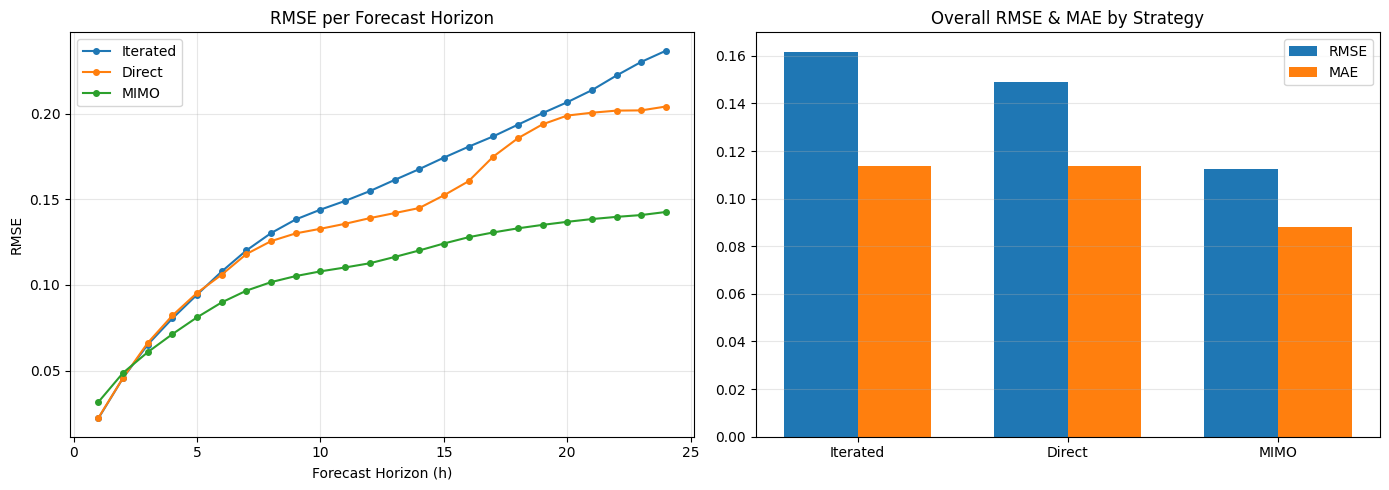

In [21]:
# 各策略逐步长 RMSE 对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 左图：逐步长 RMSE ---
ax = axes[0]
for name, y_pred in results.items():
    rmse_per_h = [
        np.sqrt(mean_squared_error(y_test[:, h], y_pred[:, h]))
        for h in range(H_NUM)
    ]
    ax.plot(range(1, H_NUM + 1), rmse_per_h, marker='o', markersize=4, label=name)
ax.set_xlabel('Forecast Horizon (h)')
ax.set_ylabel('RMSE')
ax.set_title('RMSE per Forecast Horizon')
ax.legend()
ax.grid(True, alpha=0.3)

# --- 右图：总体 RMSE / MAE 柱状图 ---
ax2 = axes[1]
names = list(results.keys())
rmses = [np.sqrt(mean_squared_error(y_test, results[n])) for n in names]
maes  = [mean_absolute_error(y_test, results[n])          for n in names]
x = np.arange(len(names))
width = 0.35
ax2.bar(x - width/2, rmses, width, label='RMSE')
ax2.bar(x + width/2, maes,  width, label='MAE')
ax2.set_xticks(x)
ax2.set_xticklabels(names)
ax2.set_title('Overall RMSE & MAE by Strategy')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
# plt.savefig('svr_strategies_comparison.png', dpi=150)
plt.show()

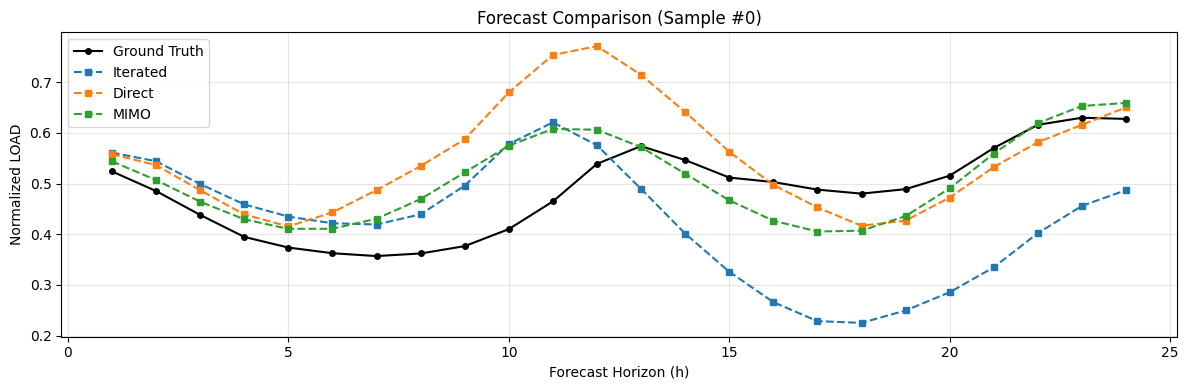

In [22]:
# 选取一个测试样本，可视化三种策略的预测曲线
sample_idx = 0

fig, ax = plt.subplots(figsize=(12, 4))
hours = range(1, H_NUM + 1)
ax.plot(hours, y_test[sample_idx], 'k-o', markersize=4, label='Ground Truth')
for name, y_pred in results.items():
    ax.plot(hours, y_pred[sample_idx], marker='s', markersize=4, linestyle='--', label=name)
ax.set_xlabel('Forecast Horizon (h)')
ax.set_ylabel('Normalized LOAD')
ax.set_title(f'Forecast Comparison (Sample #{sample_idx})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()